In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('dados_cerveja_nota.xlsx')

In [7]:
df.head()

,id,cerveja,nota
0,1,1,0.75
1,2,1,3.00
2,3,2,1.75
3,4,3,1.75
4,5,4,4.20


In [5]:
from sklearn import linear_model

In [8]:
X = df[['cerveja']] # matriz, vetor bidimensional
y = df['nota'] # vetor

In [9]:
reg = linear_model.LinearRegression()

reg.fit(X, y)

LinearRegression()

In [12]:
a, b = reg.intercept_, reg.coef_[0]
print(a, b)

np.float64(0.151612903225808)

0.151612903225808 1.0362903225806448


In [14]:
predict = reg.predict(X.drop_duplicates())
predict

array([1.18790323, 2.22419355, 3.26048387, 4.29677419, 5.33306452,
       6.36935484, 7.40564516, 8.44193548, 9.47822581])

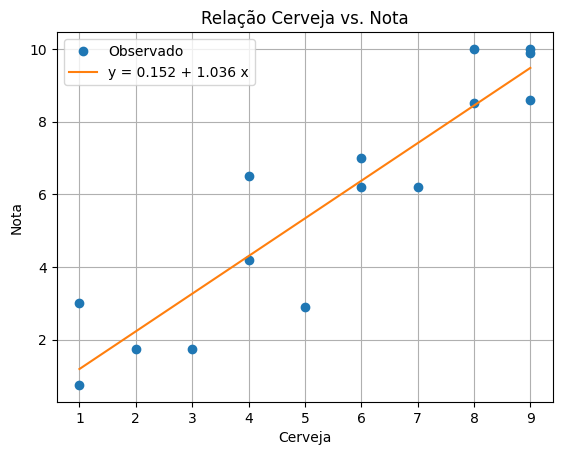

In [19]:
import matplotlib.pyplot as plt

plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja vs. Nota')
plt.xlabel('Cerveja')
plt.ylabel('Nota')

# Adicionar a reta

plt.plot(X.drop_duplicates()['cerveja'], predict)


# Adicionar legenda

plt.legend(['Observado', f'y = {a:.3f} + {b:.3f} x'])

In [20]:
# Árvore
from sklearn import tree

arvore_full = tree.DecisionTreeRegressor(random_state=42)
arvore_full.fit(X, y)

DecisionTreeRegressor(random_state=42)

In [21]:
predict_arvore_full = arvore_full.predict(X.drop_duplicates())
predict_arvore_full

array([1.875, 1.75 , 1.75 , 5.35 , 2.9  , 6.6  , 6.2  , 9.25 , 9.5  ])

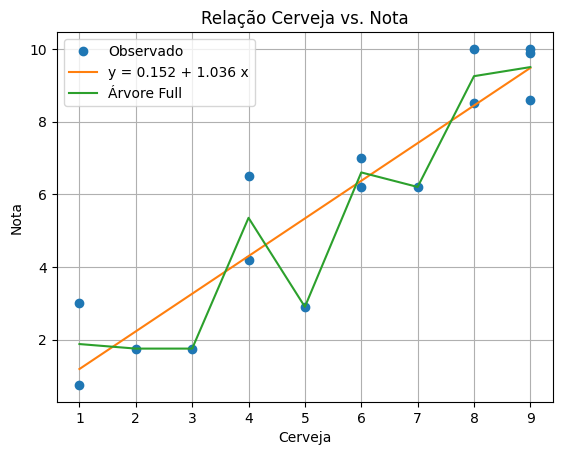

In [22]:
# Plotar com a árvore

plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja vs. Nota')
plt.xlabel('Cerveja')
plt.ylabel('Nota')

# Adicionar a reta

plt.plot(X.drop_duplicates()['cerveja'], predict)

# Adicionar árvore

plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full)

# Adicionar legenda

plt.legend(['Observado', f'y = {a:.3f} + {b:.3f} x',
            'Árvore Full'])


In [23]:
# Árvore Max Depth = 2

arvore_d2 = tree.DecisionTreeRegressor(random_state=42, max_depth=2)
arvore_d2.fit(X, y)

predict_arvore_d2 = arvore_d2.predict(X.drop_duplicates())
predict_arvore_d2

array([1.8125    , 1.8125    , 1.8125    , 4.53333333, 4.53333333,
       6.46666667, 6.46666667, 9.4       , 9.4       ])

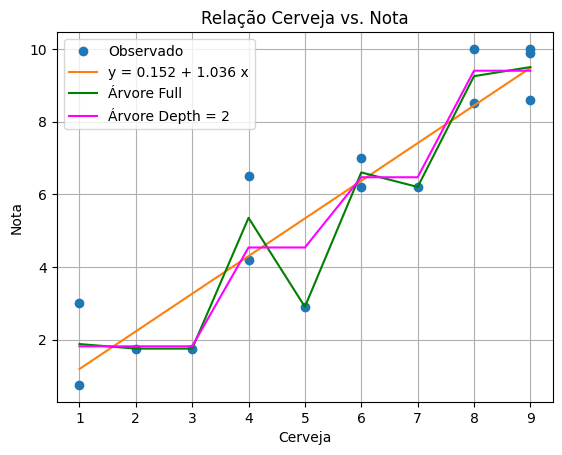

In [26]:
# Plotar com a árvore d2
plt.plot(X['cerveja'], y, 'o')
plt.grid(True)
plt.title('Relação Cerveja vs. Nota')
plt.xlabel('Cerveja')
plt.ylabel('Nota')

# Adicionar a reta

plt.plot(X.drop_duplicates()['cerveja'], predict)

# Adicionar árvore

plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_full, color='green')

# Adicionar árvore d2

plt.plot(X.drop_duplicates()['cerveja'], predict_arvore_d2, color='magenta')

# Adicionar legenda

plt.legend(['Observado', f'y = {a:.3f} + {b:.3f} x',
            'Árvore Full',
            'Árvore Depth = 2'])


[Text(0.5, 0.8333333333333334, 'cerveja <= 5.5\nsquared_error = 9.772\nsamples = 15\nvalue = 5.817'),
 Text(0.25, 0.5, 'cerveja <= 3.5\nsquared_error = 3.126\nsamples = 7\nvalue = 2.979'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.637\nsamples = 4\nvalue = 1.812'),
 Text(0.375, 0.16666666666666666, 'squared_error = 2.216\nsamples = 3\nvalue = 4.533'),
 Text(0.75, 0.5, 'cerveja <= 7.5\nsquared_error = 2.372\nsamples = 8\nvalue = 8.3'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.142\nsamples = 3\nvalue = 6.467'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.484\nsamples = 5\nvalue = 9.4')]

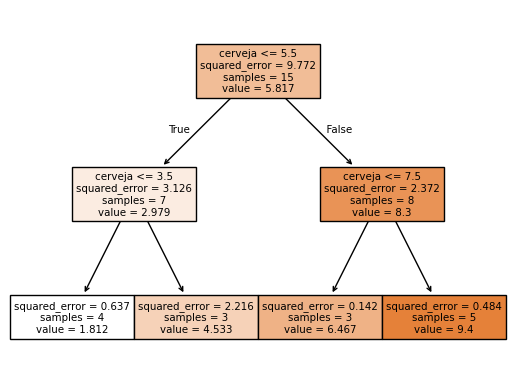

In [27]:
tree.plot_tree(arvore_d2,
               feature_names=['cerveja'],
               filled=True)